# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2587s 15us/step


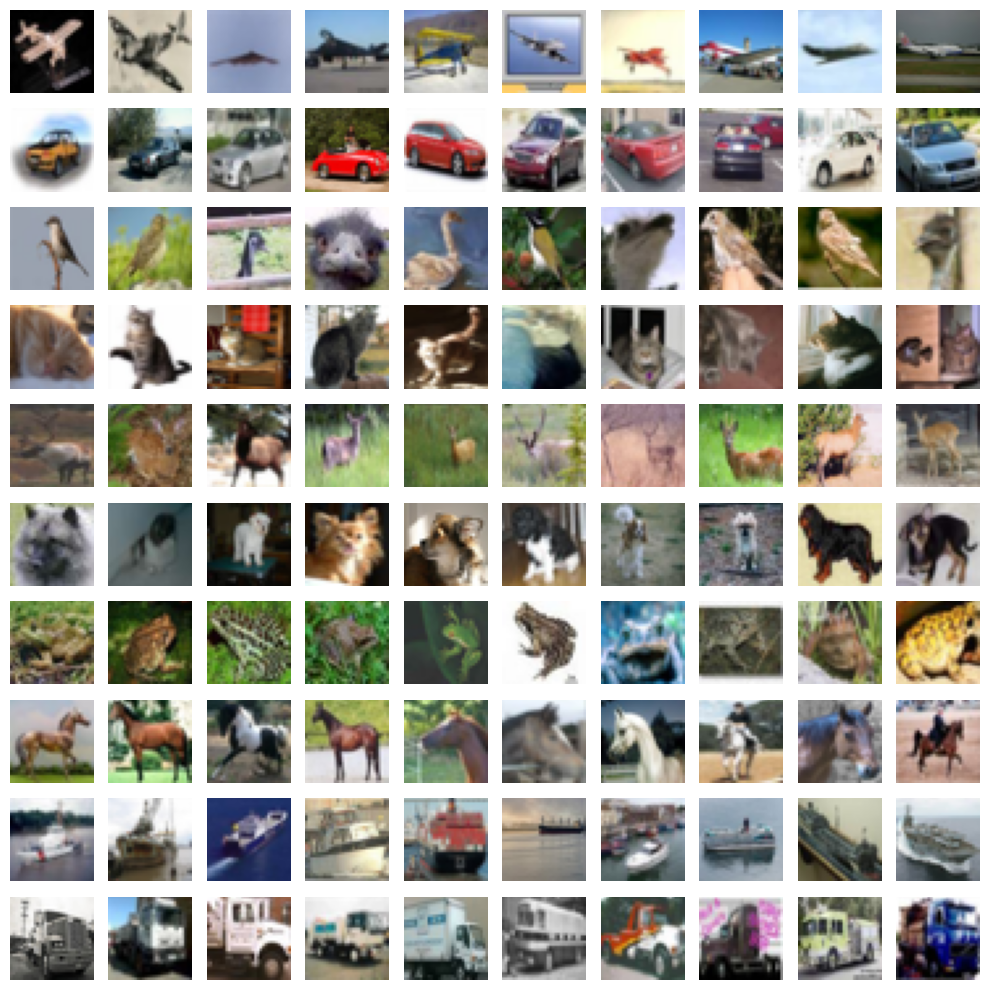

In [3]:
# Your code here :

# visualize images
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
fig, axes = plt.subplots(10, 10, figsize=(10,10))
for class_idx in range(10):
  idx = np.where(y_train.flatten() == class_idx)[0]
  sample_idx = np.random.choice(idx, 10, replace=False)
  for col, img_idx in enumerate(sample_idx):
    axes[class_idx, col].imshow(x_train[img_idx])
    axes[class_idx, col].axis('off')


plt.tight_layout()
plt.show()

# convert encoded form
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh = to_categorical(y_test, num_classes=10)

# normalize image
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [4]:
from keras.backend import clear_session
clear_session()

In [5]:
# Your code here :
# Your code here :
from tensorflow import keras
from tensorflow.keras import layers, models


model = models.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(100, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [6]:
# Your code here :
model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
history = model.fit(
    x_train_norm, y_train_oh,
    validation_data=(x_test_norm, y_test_oh),
    epochs=50,
    batch_size=512
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.1622 - loss: 2.2629 - val_accuracy: 0.2028 - val_loss: 2.2147
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2363 - loss: 2.1595 - val_accuracy: 0.2417 - val_loss: 2.1049
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2764 - loss: 2.0514 - val_accuracy: 0.3014 - val_loss: 2.0071
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3112 - loss: 1.9705 - val_accuracy: 0.3177 - val_loss: 1.9364
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3308 - loss: 1.9177 - val_accuracy: 0.3232 - val_loss: 1.9065
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3458 - loss: 1.8800 - val_accuracy: 0.3560 - val_loss: 1.8601
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3540 - loss: 1.8514 - val_accuracy: 0.3637 - val_loss: 1.8309
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3651 - loss: 1.8235 - val_accuracy: 0.3691 - v

*   Plot the cross entropy loss curve and the accuracy curve

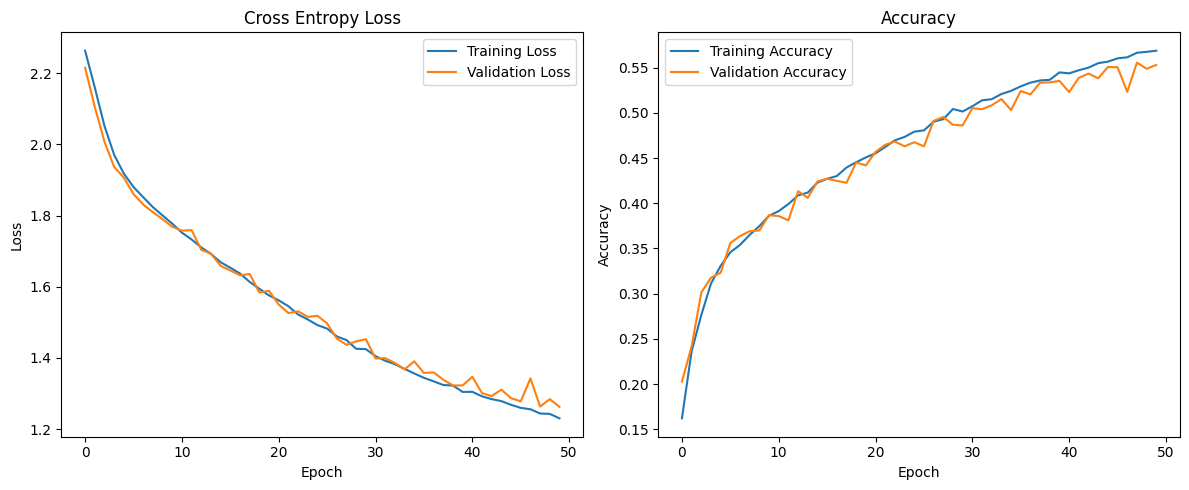

In [7]:
# Your code here :

import matplotlib.pyplot as plt

# Plot loss curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Cross Entropy Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [27]:
from keras.backend import clear_session
clear_session()

In [28]:
# Your code here :
import tensorflow as tf

x_train_resized = tf.image.resize(x_train_norm, (64, 64))
x_test_resized = tf.image.resize(x_test_norm, (64, 64))


from tensorflow import keras
from tensorflow.keras import layers, models
vgg_model = models.Sequential([
    keras.Input(shape=(64, 64, 3)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(256, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.Conv2D(256, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [29]:
# Your code here :
vgg_model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
vgg_history = vgg_model.fit(
    x_train_resized, y_train_oh,
    validation_data=(x_test_resized, y_test_oh),
    epochs=50,
    batch_size=512
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 92s 917ms/step - accuracy: 0.1130 - loss: 2.2990 - val_accuracy: 0.1204 - val_loss: 2.2950
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 406ms/step - accuracy: 0.1255 - loss: 2.2883 - val_accuracy: 0.1674 - val_loss: 2.2766
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 406ms/step - accuracy: 0.1977 - loss: 2.2352 - val_accuracy: 0.1974 - val_loss: 2.1640
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 405ms/step - accuracy: 0.2331 - loss: 2.1245 - val_accuracy: 0.2785 - val_loss: 2.0336
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 405ms/step - accuracy: 0.2851 - loss: 2.0241 - val_accuracy: 0.3314 - val_loss: 1.9045
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 403ms/step - accuracy: 0.3200 - loss: 1.9383 - val_accuracy: 0.3602 - val_loss: 1.8367
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 405ms/step - accuracy: 0.3422 - loss: 1.8603 - val_accuracy: 0.3470 - val_loss: 1.8242
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 410ms/step - accuracy: 0.3630 - loss: 1.8017 - val_accu

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


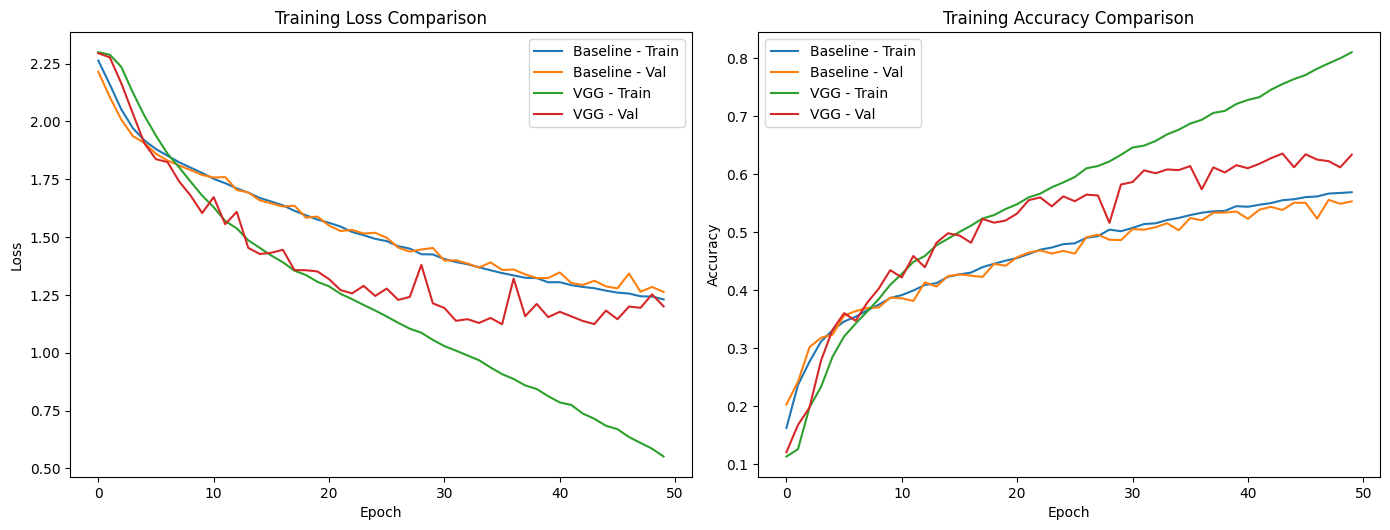

Baseline - Final Train Acc: 0.5686, Final Val Acc: 0.5529
VGG      - Final Train Acc: 0.8100, Final Val Acc: 0.6333


In [30]:
# Your code here :

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# Loss comparison
plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Baseline - Train')
plt.plot(history.history['val_loss'], label='Baseline - Val')
plt.plot(vgg_history.history['loss'], label='VGG - Train')
plt.plot(vgg_history.history['val_loss'], label='VGG - Val')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy comparison
plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Baseline - Train')
plt.plot(history.history['val_accuracy'], label='Baseline - Val')
plt.plot(vgg_history.history['accuracy'], label='VGG - Train')
plt.plot(vgg_history.history['val_accuracy'], label='VGG - Val')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Print final epoch numbers for a quick numeric comparison
print(f"Baseline - Final Train Acc: {history.history['accuracy'][-1]:.4f}, Final Val Acc: {history.history['val_accuracy'][-1]:.4f}")
print(f"VGG      - Final Train Acc: {vgg_history.history['accuracy'][-1]:.4f}, Final Val Acc: {vgg_history.history['val_accuracy'][-1]:.4f}")

**Comment on the observation**

*(Double-click or enter to edit)*
#  performs better
...

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step


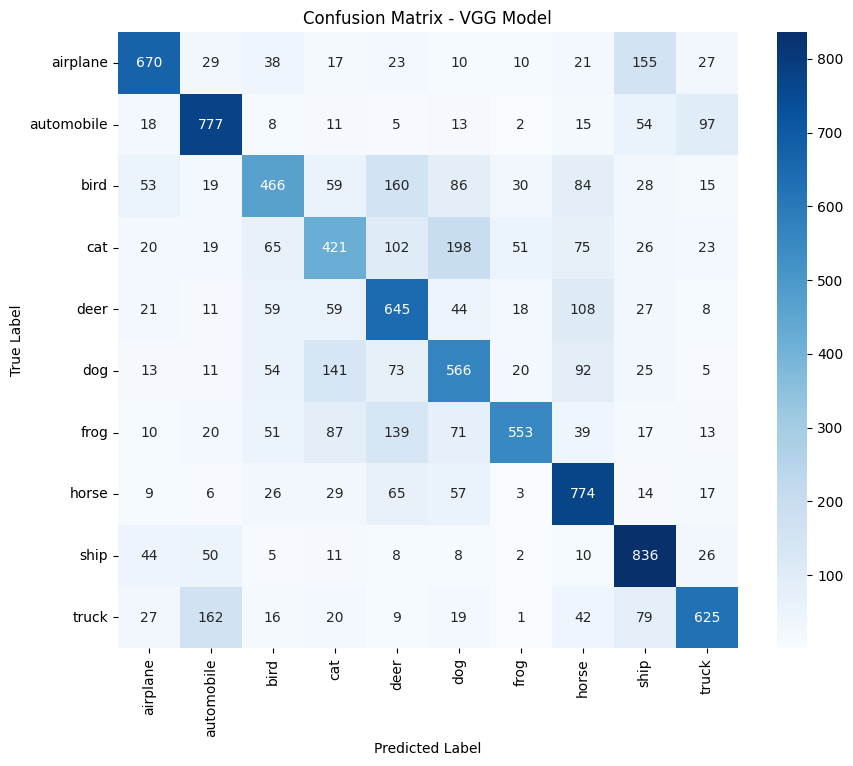

In [31]:
# Your code here :

import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Predict probabilities on the (resized) test set
y_pred_probs = vgg_model.predict(x_test_resized)

# Convert softmax probabilities
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot true labels
y_true = np.argmax(y_test_oh, axis=1)


cm = confusion_matrix(y_true, y_pred)

# Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - VGG Model')
plt.show()

**Comment here :**

*(Double-click or enter to edit)*

...

63.3% test accuracy

*    Print the test accuracy for the trained model.

In [38]:
# Your code here :

vgg_model.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])
test_loss, test_accuracy = vgg_model.evaluate(x_test_resized, y_test_oh)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.0998 - loss: 2.3031
Test Accuracy: 0.0998
Test Loss: 2.3031


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [32]:
from keras.backend import clear_session
clear_session()

In [40]:
# Your code here :
from tensorflow import keras
from tensorflow.keras import layers, models

vgg_model2 = models.Sequential([
    keras.Input(shape=(64, 64, 3)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.Conv2D(256, kernel_size=(3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),  # classification layer — softmax, not relu
])

vgg_model2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 44s 430ms/step - accuracy: 0.1438 - loss: 2.2996 - val_accuracy: 0.1988 - val_loss: 2.2951
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 78s 410ms/step - accuracy: 0.2179 - loss: 2.2867 - val_accuracy: 0.2285 - val_loss: 2.2713
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 39s 402ms/step - accuracy: 0.2190 - loss: 2.2175 - val_accuracy: 0.1903 - val_loss: 2.1603
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 407ms/step - accuracy: 0.2409 - loss: 2.1175 - val_accuracy: 0.2460 - val_loss: 2.1060
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 405ms/step - accuracy: 0.2899 - loss: 2.0227 - val_accuracy: 0.3210 - val_loss: 1.9198
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 407ms/step - accuracy: 0.3182 - loss: 1.9442 - val_accuracy: 0.3515 - val_loss: 1.8485
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 407ms/step - accuracy: 0.3396 - loss: 1.8677 - val_accuracy: 0.3602 - val_loss: 1.7971
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 40s 407ms/step - accuracy: 0.3611 - loss: 1.8032 - val_accu

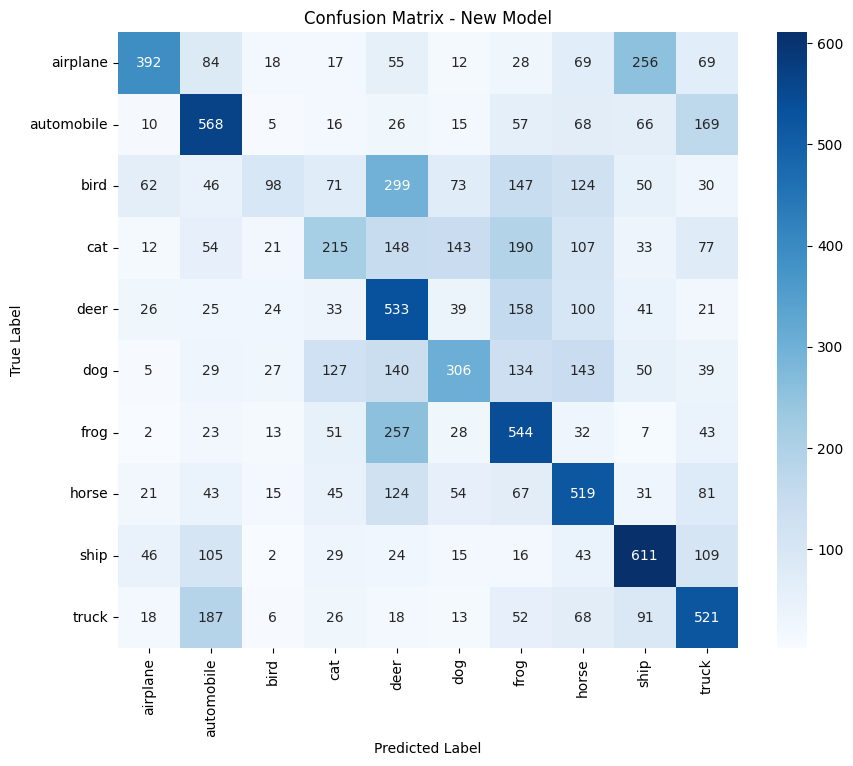

In [41]:
# Your code here :

# 1. Compile
vgg_model2.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

# 2. Train for 10 epochs, batch size 512
vgg_model2_history = vgg_model2.fit(
    x_train_resized, y_train_oh,        # use x_train_norm if this model takes 32x32 input instead
    validation_data=(x_test_resized, y_test_oh),
    epochs=10,
    batch_size=512
)

# 3. Predict and plot confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

y_pred_probs = vgg_model2.predict(x_test_resized)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_oh, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - New Model')
plt.show()

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:



_

2 - Key Differences between sigmoid and softmax:



_

3 - Key Differences between categorical crossentropy and binary crossentropy loss:


_
